# 02 - Nettoyage, pretraitement et analyse exploratoire

**Projet ST2MLE - Analyse des offres d'emploi en France**

On part des donnees brutes (`data/raw/offres_brut.csv`) collectees au notebook 01, on produit un jeu de donnees **propre et pret a modeliser** (`data/processed/offres_clean.parquet`), puis on realise l'**analyse exploratoire**.

Objectifs de modelisation (notebooks suivants) :
- **Regression** : predire le **salaire annuel brut**.
- **Classification textuelle** : predire le **metier**, le **secteur** et le **type de contrat** a partir de la description.

Plan :
- **Partie A - Pretraitement** : nettoyage, cibles, variables explicatives, echantillonnage, filtre langue, traitement du texte francais.
- **Partie B - Exploration** : distributions, croisements, analyse geographique, analyse textuelle, correlations.

---
# Partie A - Nettoyage et pretraitement

In [3]:
import re
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option('display.max_colwidth', 80)

df = pd.read_csv('data/raw/offres_brut.csv', low_memory=False)
print('Offres brutes :', df.shape)
df.head(3)

Offres brutes : (280307, 29)


,id,intitule,rome_code,rome_libelle,appellation_libelle,secteur_activite,secteur_activite_libelle,type_contrat,type_contrat_libelle,nature_contrat,...,alternance,qualification_libelle,lieu_libelle,code_postal,commune,latitude,longitude,entreprise_nom,date_creation,date_actualisation
0,209ZZGK,ASSISTANT ADMINISTRATIF (H/F),M1607,Assistant administratif / Assistante administrative,Assistant administratif / Assistante administrative,47.0,Supermarchés,CDI,CDI,Contrat travail,...,False,Employé qualifié,01 - Gex,1170.0,01173,46.333994,6.058167,INTERMARCHE,2026-06-19T13:14:40.933Z,2026-06-19T13:14:41.098Z
1,209ZYHX,OPERATEUR H/F,H3204,Opérateur / Opératrice de production des matières plastiques et du caoutchouc,Opérateur / Opératrice en plasturgie,78.0,Activités des agences de travail temporaire,MIS,Intérim - 6 Mois,Contrat travail,...,False,"Ouvrier qualifié (P3,P4,OHQ)",01 - Oyonnax,1100.0,01283,46.272320,5.628447,ADEQUAT 045,2026-06-19T12:28:24.189Z,2026-06-19T12:29:50.479Z
2,209ZWCS,Assistant médical (H/F),J1303,Assistant / Assistante médico-technique,Assistant médical / Assistante médicale,84.0,Administration publique générale,CDI,CDI,Contrat travail,...,False,Employé qualifié,01 - BOURG EN BRESSE,1000.0,01053,46.205296,5.224853,CA DU BASSIN DE BOURG-EN-BRESSE,2026-06-19T11:43:04.944Z,2026-06-19T11:52:32.114Z


## A.1 Nettoyage de base

On supprime les **doublons** (par identifiant d'offre) et les offres dont la **description est absente ou trop courte** (< 100 caracteres), car elles sont inexploitables pour le NLP.

In [4]:
avant = len(df)
df = df.drop_duplicates(subset='id')
df = df[df['description'].notna() & (df['description'].str.len() >= 100)].copy()
print(f'{avant:,} -> {len(df):,} offres apres suppression doublons + descriptions trop courtes')

280,307 -> 279,608 offres apres suppression doublons + descriptions trop courtes


## A.2 Construction des cibles

### A.2.1 Salaire annuel brut (cible de regression)

Le salaire est fourni sous forme de **texte libre** tres heterogene :
```
Mensuel de 2000.0 Euros a 2300.0 Euros sur 12.0 mois
Annuel de 28000.0 Euros a 33000.0 Euros sur 12 mois
Horaire de 12.31 Euros sur 12 mois
```
On le convertit en un **salaire annuel brut** unique :
- on extrait les montants (et on prend la **moyenne** si fourchette) ;
- selon la periode : `Annuel` -> tel quel ; `Mensuel` -> x nombre de mois ; `Horaire` -> x 1820 h/an (35h x 52 semaines) ;
- on applique un **filtre de coherence** [10 000 ; 250 000] euros qui elimine au passage les libelles mal etiquetes (ex. un "horaire" a 1960 = en fait un mensuel).

In [5]:
HEURES_PAR_AN = 35 * 52  # 1820 h/an a temps plein
_NB = re.compile(r'(\d+(?:[.,]\d+)?)\s*Euro', re.IGNORECASE)
_MOIS = re.compile(r'sur\s+(\d+(?:[.,]\d+)?)\s*mois', re.IGNORECASE)

def parser_salaire(libelle):
    if not isinstance(libelle, str) or not libelle.strip():
        return np.nan
    montants = [float(x.replace(',', '.')) for x in _NB.findall(libelle)]
    if not montants:
        return np.nan
    base = float(np.mean(montants))                       # moyenne de la fourchette
    m = _MOIS.search(libelle)
    n_mois = float(m.group(1).replace(',', '.')) if m else 12.0
    t = libelle.lower()
    if t.startswith('annuel'):
        annuel = base
    elif t.startswith('mensuel'):
        annuel = base * n_mois
    elif t.startswith('horaire'):
        annuel = base * HEURES_PAR_AN
    else:
        annuel = base * n_mois
    if annuel < 10_000 or annuel > 250_000:               # filtre de coherence
        return np.nan
    return round(annuel, 2)

df['salaire_annuel'] = df['salaire_libelle'].map(parser_salaire)
print('Salaire renseigne :', df['salaire_annuel'].notna().sum(), '/', len(df))
df['salaire_annuel'].describe().round(0)

Salaire renseigne : 152761 / 279608


count    152761.0
mean      27011.0
std       10177.0
min       10000.0
25%       22416.0
50%       24360.0
75%       28188.0
max      250000.0
Name: salaire_annuel, dtype: float64

### A.2.2 Metier (cible de classification)

Le code **ROME** compte ~1 700 valeurs distinctes : beaucoup trop pour une classification. On le regroupe par sa **1ere lettre**, qui correspond aux **14 grands domaines professionnels** ROME (A a N). C'est interpretable et bien plus equilibre.

In [6]:
DOMAINES_ROME = {
    'A': 'Agriculture et Peche',
    'B': "Arts et Faconnage d'ouvrages d'art",
    'C': 'Banque, Assurance, Immobilier',
    'D': 'Commerce, Vente et Grande distribution',
    'E': 'Communication, Media et Multimedia',
    'F': 'Construction, Batiment et Travaux publics',
    'G': 'Hotellerie-Restauration, Tourisme, Loisirs',
    'H': 'Industrie',
    'I': 'Installation et Maintenance',
    'J': 'Sante',
    'K': 'Services a la personne et a la collectivite',
    'L': 'Spectacle',
    'M': "Support a l'entreprise",
    'N': 'Transport et Logistique',
}

def domaine_metier(rome_code):
    if not isinstance(rome_code, str) or not rome_code:
        return np.nan
    return DOMAINES_ROME.get(rome_code[0].upper(), np.nan)

df['cible_metier'] = df['rome_code'].map(domaine_metier)
df['cible_metier'].value_counts()

cible_metier
Services a la personne et a la collectivite    44919
Industrie                                      34555
Commerce, Vente et Grande distribution         34192
Hotellerie-Restauration, Tourisme, Loisirs     26004
Construction, Batiment et Travaux publics      25918
Support a l'entreprise                         25624
Transport et Logistique                        25262
Sante                                          24351
Installation et Maintenance                    22563
Agriculture et Peche                            7323
Banque, Assurance, Immobilier                   5794
Communication, Media et Multimedia              2009
Arts et Faconnage d'ouvrages d'art               587
Spectacle                                        507
Name: count, dtype: int64

### A.2.3 Secteur d'activite (cible de classification)

Le secteur est fourni par le code **NAF/APE a 2 chiffres** (la *division*). On le regroupe vers la **section NAF** (~21 grandes categories : Industrie, Construction, Commerce, Sante...), plus lisible que 685 libelles distincts.

In [7]:
SECTIONS_NAF = [
    (1, 3, 'Agriculture, sylviculture et peche'),
    (5, 9, 'Industries extractives'),
    (10, 33, 'Industrie manufacturiere'),
    (35, 35, 'Electricite, gaz, vapeur'),
    (36, 39, 'Eau, assainissement, dechets'),
    (41, 43, 'Construction'),
    (45, 47, 'Commerce, reparation automobile'),
    (49, 53, 'Transports et entreposage'),
    (55, 56, 'Hebergement et restauration'),
    (58, 63, 'Information et communication'),
    (64, 66, 'Activites financieres et assurance'),
    (68, 68, 'Activites immobilieres'),
    (69, 75, 'Activites scientifiques et techniques'),
    (77, 82, 'Services administratifs et de soutien'),
    (84, 84, 'Administration publique'),
    (85, 85, 'Enseignement'),
    (86, 88, 'Sante humaine et action sociale'),
    (90, 93, 'Arts, spectacles et loisirs'),
    (94, 96, 'Autres activites de services'),
    (97, 98, 'Activites des menages employeurs'),
    (99, 99, 'Organisations extraterritoriales'),
]

def section_naf(division):
    if pd.isna(division):
        return np.nan
    try:
        d = int(float(division))
    except (ValueError, TypeError):
        return np.nan
    for lo, hi, lib in SECTIONS_NAF:
        if lo <= d <= hi:
            return lib
    return np.nan

df['cible_secteur'] = df['secteur_activite'].map(section_naf)
df['cible_secteur'].value_counts()

cible_secteur
Services administratifs et de soutien    97839
Sante humaine et action sociale          31342
Commerce, reparation automobile          18954
Hebergement et restauration              16404
Activites scientifiques et techniques    13542
Industrie manufacturiere                 13440
Enseignement                              8842
Construction                              8292
Administration publique                   7236
Autres activites de services              5724
Transports et entreposage                 5635
Activites financieres et assurance        3153
Activites immobilieres                    2518
Arts, spectacles et loisirs               2066
Agriculture, sylviculture et peche        1844
Information et communication              1750
Eau, assainissement, dechets               860
Electricite, gaz, vapeur                   427
Activites des menages employeurs           303
Industries extractives                      71
Organisations extraterritoriales             2

### A.2.4 Type de contrat (cible de classification)

On utilise le **code** de contrat (propre) plutot que le libelle (qui melange la duree : *CDD - 12 Mois*). On regroupe les codes rares dans `Autre`.

In [8]:
CONTRATS = {'CDI': 'CDI', 'CDD': 'CDD', 'MIS': 'Interim', 'SAI': 'Saisonnier', 'LIB': 'Liberal'}

def grouper_contrat(code):
    if not isinstance(code, str) or not code:
        return np.nan
    return CONTRATS.get(code, 'Autre')

df['cible_contrat'] = df['type_contrat'].map(grouper_contrat)
df['cible_contrat'].value_counts()

cible_contrat
CDI           132092
Interim        70332
CDD            62847
Saisonnier      6267
Autre           4129
Liberal         3941
Name: count, dtype: int64

## A.3 Variables explicatives annexes

Variables utiles surtout pour le **modele de salaire** :
- `exp_annees` : experience demandee convertie en annees (`Debutant` -> 0, `2 An(s)` -> 2, `6 Mois` -> 0.5) ;
- `departement` : extrait du code postal ;
- `temps_plein` : booleen depuis la duree de travail ;
- `alternance` : booleen.

In [9]:
def parser_experience(libelle):
    if not isinstance(libelle, str):
        return np.nan
    t = libelle.lower()
    if 'debutant' in t or 'd\u00e9butant' in t:
        return 0.0
    m = re.search(r'(\d+)\s*an', t)
    if m:
        return float(m.group(1))
    m = re.search(r'(\d+)\s*mois', t)
    if m:
        return round(float(m.group(1)) / 12, 2)
    return np.nan

def departement(code_postal):
    if pd.isna(code_postal):
        return np.nan
    try:
        cp = f'{int(float(code_postal)):05d}'
    except (ValueError, TypeError):
        return np.nan
    return '97' + cp[2] if cp.startswith('97') else cp[:2]

df['exp_annees'] = df['experience_libelle'].map(parser_experience)
df['departement'] = df['code_postal'].map(departement)
df['temps_plein'] = (df['duree_travail_converti'] == 'Temps plein').astype('Int64')
df['alternance'] = df['alternance'].astype('boolean')
df[['exp_annees', 'departement', 'temps_plein', 'alternance']].head()

,exp_annees,departement,temps_plein,alternance
0,2.0,01,1,False
1,3.0,01,1,False
2,0.0,01,1,False
3,0.0,01,1,False
4,1.0,01,1,False


## A.4 Echantillonnage

Le corpus complet (~280 000 offres) est lourd a lemmatiser puis a vectoriser avec BERT. On tire un **echantillon aleatoire de 20 000 offres** (`random_state=42` pour la reproductibilite) : largement au-dessus du minimum de 1 000 lignes impose, et suffisant pour entrainer/comparer les modeles.

In [10]:
TAILLE = min(20_000, len(df))
df = df.sample(n=TAILLE, random_state=42).reset_index(drop=True)
print('Echantillon :', df.shape)

Echantillon : (20000, 36)


## A.5 Filtre langue francaise

Le sujet impose des **textes en francais uniquement**. Quelques offres (postes internationaux) sont en anglais : on les detecte avec `langdetect` et on ne garde que le francais.

In [11]:
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42  # resultat reproductible

def est_francais(txt):
    try:
        return detect(txt[:600]) == 'fr'
    except Exception:
        return False

masque_fr = df['description'].map(est_francais)
print('Non francais retires :', (~masque_fr).sum())
df = df[masque_fr].reset_index(drop=True)
print('Offres francaises :', len(df))

Non francais retires : 21
Offres francaises : 19979


## A.6 Pretraitement textuel francais

On construit le texte a analyser en concatenant **intitule + description**, puis :
1. **Nettoyage de surface** : suppression du HTML, des URLs, passage en minuscules, suppression de la ponctuation/chiffres (on garde les accents francais).
2. **Lemmatisation francaise** avec spaCy (`fr_core_news_sm`) : on ramene chaque mot a sa forme canonique (*recrutons* -> *recruter*), on retire les **stopwords francais** + une liste metier (mots trop frequents et peu informatifs : *poste*, *profil*, *mission*...) et les tokens de moins de 3 lettres.

> La lemmatisation FR (plutot que le stemming) est recommandee pour le francais : elle gere mieux les accords et conjugaisons.

In [12]:
_HTML = re.compile(r'<[^>]+>')
_URL = re.compile(r'http\S+|www\.\S+')
_NONALPHA = re.compile(r'[^a-zA-Z\u00e0\u00e2\u00e4\u00e9\u00e8\u00ea\u00eb\u00ef\u00ee\u00f4\u00f6\u00f9\u00fb\u00fc\u00e7\u0153\s]', re.IGNORECASE)
_SPACES = re.compile(r'\s+')

def nettoyer_texte(txt):
    if not isinstance(txt, str):
        return ''
    txt = _HTML.sub(' ', txt)
    txt = _URL.sub(' ', txt)
    txt = txt.lower()
    txt = _NONALPHA.sub(' ', txt)
    return _SPACES.sub(' ', txt).strip()

df['texte_brut'] = df['intitule'].fillna('') + '. ' + df['description'].fillna('')
df['texte_propre'] = df['texte_brut'].map(nettoyer_texte)
df[['intitule', 'texte_propre']].head(3)

,intitule,texte_propre
0,Responsable de centre de profit (H/F),responsable de centre de profit h f description du poste nous recherchons un...
1,Hôte Vendeur - Albi F/H,hôte vendeur albi f h entreprise vous n imaginez pas ce que ce métier peut v...
2,Apprenti Assistant Dentaire (H/F),apprenti assistant dentaire h f dans le cadre d un contrat d apprentissage r...


In [13]:
import spacy
from tqdm.auto import tqdm

nlp = spacy.load('fr_core_news_sm')
stopwords = set(nlp.Defaults.stop_words) | {
    'profil', 'poste', 'mission', 'candidat', 'candidate', 'entreprise',
    'recherche', 'rechercher', 'rejoindre', 'equipe', 'client', 'travail',
    'experience', 'salaire', 'contrat', 'heure', 'jour', 'semaine', 'mois',
    'annee', 'type', 'lieu', 'ville',
}

# n_process > 1 parallelise la lemmatisation sur plusieurs coeurs.
# Sous Windows, le multiprocessing peut echouer (spawn/pickling) : on retombe
# alors automatiquement sur un seul process.
def lemmatiser(textes, batch_size=200, n_process=4, max_len=5000):
    textes = [t[:max_len] for t in textes]  # tronque les offres tres longues

    def _run(n_proc):
        out = []
        for doc in tqdm(
            nlp.pipe(textes, batch_size=batch_size, n_process=n_proc,
                     disable=['parser', 'ner']),
            total=len(textes), desc='Lemmatisation',
        ):
            out.append(' '.join(
                t.lemma_ for t in doc
                if t.is_alpha and t.lemma_ not in stopwords and len(t.lemma_) > 2
            ))
        return out

    try:
        return _run(n_process)
    except Exception as e:
        print(f'Multiprocessing indisponible ({e}); repli sur 1 process.')
        return _run(1)

df['texte_lemmatise'] = lemmatiser(df['texte_propre'].tolist())
# retire les offres dont le texte est devenu trop court apres nettoyage
df = df[df['texte_lemmatise'].str.split().str.len() >= 5].reset_index(drop=True)
print('Offres finales :', len(df))
df[['texte_lemmatise']].head(3)

Lemmatisation:   0%|          | 0/19979 [00:00<?, ?it/s]

Offres finales : 19978


,texte_lemmatise
0,responsable centre profit description adjoint chef agence cdi baser sein age...
1,hôte vendeur albi entreprendre imaginer métier pouvoir apporter guider métie...
2,apprenti assister dentaire cadre apprentissage règlementé vue obtention dipl...


## A.7 Sauvegarde du jeu de donnees propre

On conserve les cibles, les variables explicatives et le texte (brut nettoye + lemmatise) dans `data/processed/`. Ce fichier sera le point d'entree des notebooks de modelisation.

In [ ]:
cols = [
    'id', 'intitule',
    'salaire_annuel', 'cible_metier', 'cible_secteur', 'cible_contrat',
    'exp_annees', 'experience_exige', 'temps_plein', 'alternance',
    'departement', 'qualification_libelle', 'type_contrat',
    'rome_code', 'rome_libelle', 'secteur_activite_libelle',
    'texte_propre', 'texte_lemmatise',
]
df_clean = df[cols].copy()

Path('data/processed').mkdir(parents=True, exist_ok=True)
df_clean.to_parquet('data/processed/offres_clean.parquet', index=False)
df_clean.to_csv('data/processed/offres_clean.csv', index=False, encoding='utf-8')

print('Sauvegarde :', df_clean.shape)
print('Salaire renseigne :', df_clean['salaire_annuel'].notna().sum())
df_clean.head()

---
# Partie B - Analyse exploratoire et visualisations

On explore le jeu de donnees nettoye (la variable `df_clean` produite ci-dessus) :
- distributions des cibles (salaire, metier, secteur, contrat) ;
- analyse geographique ;
- analyse textuelle (longueur, mots frequents, nuages de mots) ;
- correlations entre variables numeriques.

Ces analyses guident les choix de modelisation (equilibre des classes, variables pertinentes, etc.).

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# On repart du dataframe nettoye produit en Partie A
df = df_clean.copy()
print('Offres :', df.shape)
df.head(3)

Offres : (19978, 18)


,id,intitule,salaire_annuel,cible_metier,cible_secteur,cible_contrat,exp_annees,experience_exige,temps_plein,alternance,departement,qualification_libelle,type_contrat,rome_code,rome_libelle,secteur_activite_libelle,texte_propre,texte_lemmatise
0,2827456,Responsable de centre de profit (H/F),NaN,Support a l'entreprise,NaN,CDI,3.0,E,0,False,43,NaN,CDI,M1302,Responsable de Petite ou Moyenne Entreprise -PME-,NaN,responsable de centre de profit h f description du poste nous recherchons un...,responsable centre profit description adjoint chef agence cdi baser sein age...
1,3980908,Hôte Vendeur - Albi F/H,NaN,Services a la personne et a la collectivite,NaN,CDI,0.0,D,1,False,81,Employé qualifié,CDI,K2602,Conseiller / Conseillère funéraire,NaN,hôte vendeur albi f h entreprise vous n imaginez pas ce que ce métier peut v...,hôte vendeur albi entreprendre imaginer métier pouvoir apporter guider métie...
2,209SRXL,Apprenti Assistant Dentaire (H/F),NaN,Sante,Activites financieres et assurance,CDD,0.0,D,1,True,59,Employé qualifié,CDD,J1312,Assistant / Assistante dentaire,Supports juridiques de gestion de patrimoine mobilier,apprenti assistant dentaire h f dans le cadre d un contrat d apprentissage r...,apprenti assister dentaire cadre apprentissage règlementé vue obtention dipl...


## B.1 Distribution du salaire annuel brut

Cible du modele de regression. On observe sa distribution (souvent asymetrique a droite) et quelques statistiques.

count     10808.0
mean      27082.0
std       10056.0
min       10000.0
25%       22422.0
50%       24570.0
75%       28360.0
max      239616.0
Name: salaire_annuel, dtype: float64


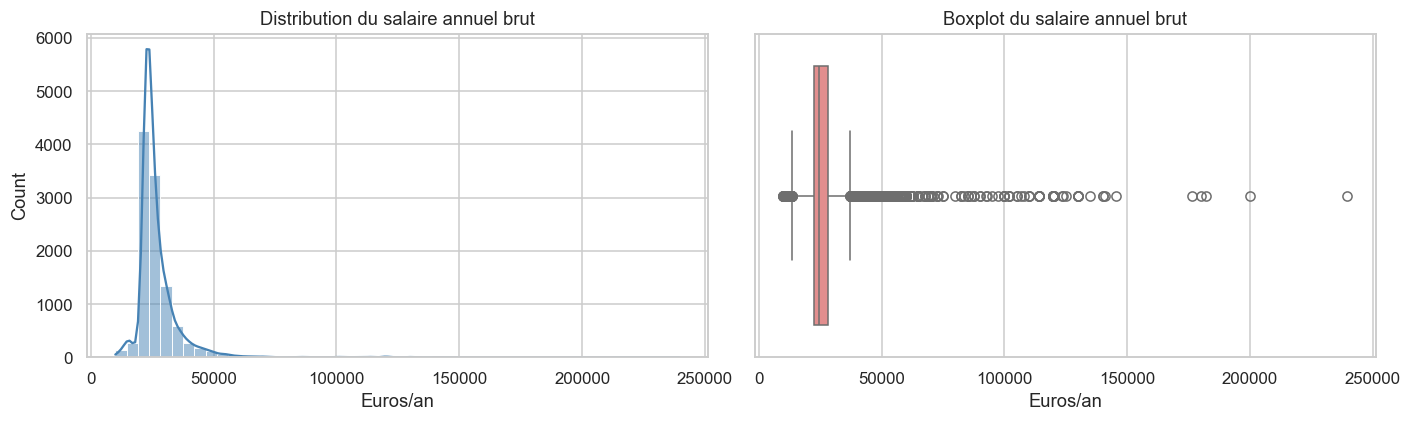

In [16]:
sal = df['salaire_annuel'].dropna()
print(sal.describe().round(0))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(sal, bins=50, kde=True, ax=ax[0], color='steelblue')
ax[0].set(title='Distribution du salaire annuel brut', xlabel='Euros/an')
sns.boxplot(x=sal, ax=ax[1], color='lightcoral')
ax[1].set(title='Boxplot du salaire annuel brut', xlabel='Euros/an')
plt.tight_layout(); plt.show()

## B.2 Distribution des cibles de classification

Le **desequilibre des classes** est important a reperer : il influencera le choix des metriques (accuracy vs F1 macro) et eventuellement un reequilibrage.

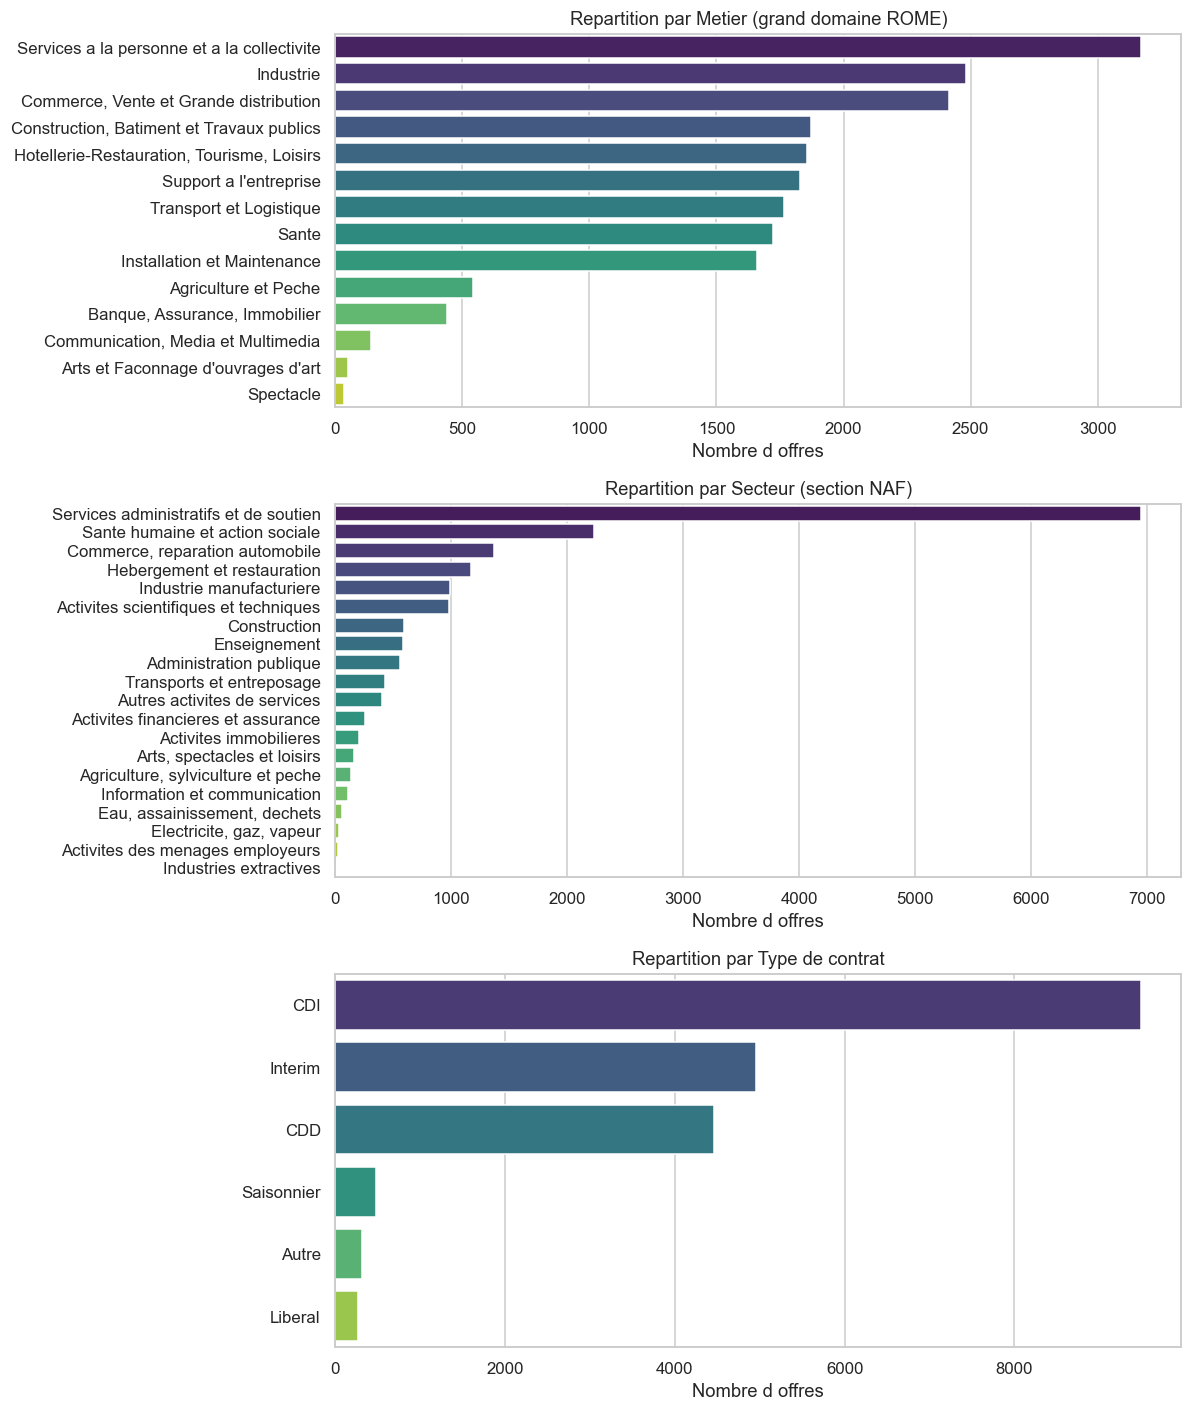

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(11, 13))
for ax, col, titre in zip(
    axes,
    ['cible_metier', 'cible_secteur', 'cible_contrat'],
    ['Metier (grand domaine ROME)', 'Secteur (section NAF)', 'Type de contrat'],
):
    vc = df[col].value_counts()
    sns.barplot(x=vc.values, y=vc.index, ax=ax, palette='viridis', hue=vc.index, legend=False)
    ax.set(title=f'Repartition par {titre}', xlabel='Nombre d offres', ylabel='')
plt.tight_layout(); plt.show()

## B.3 Salaire selon le metier et le type de contrat

Croisement des variables : quels domaines/contrats sont les mieux remuneres ? Utile pour les recommandations metier.

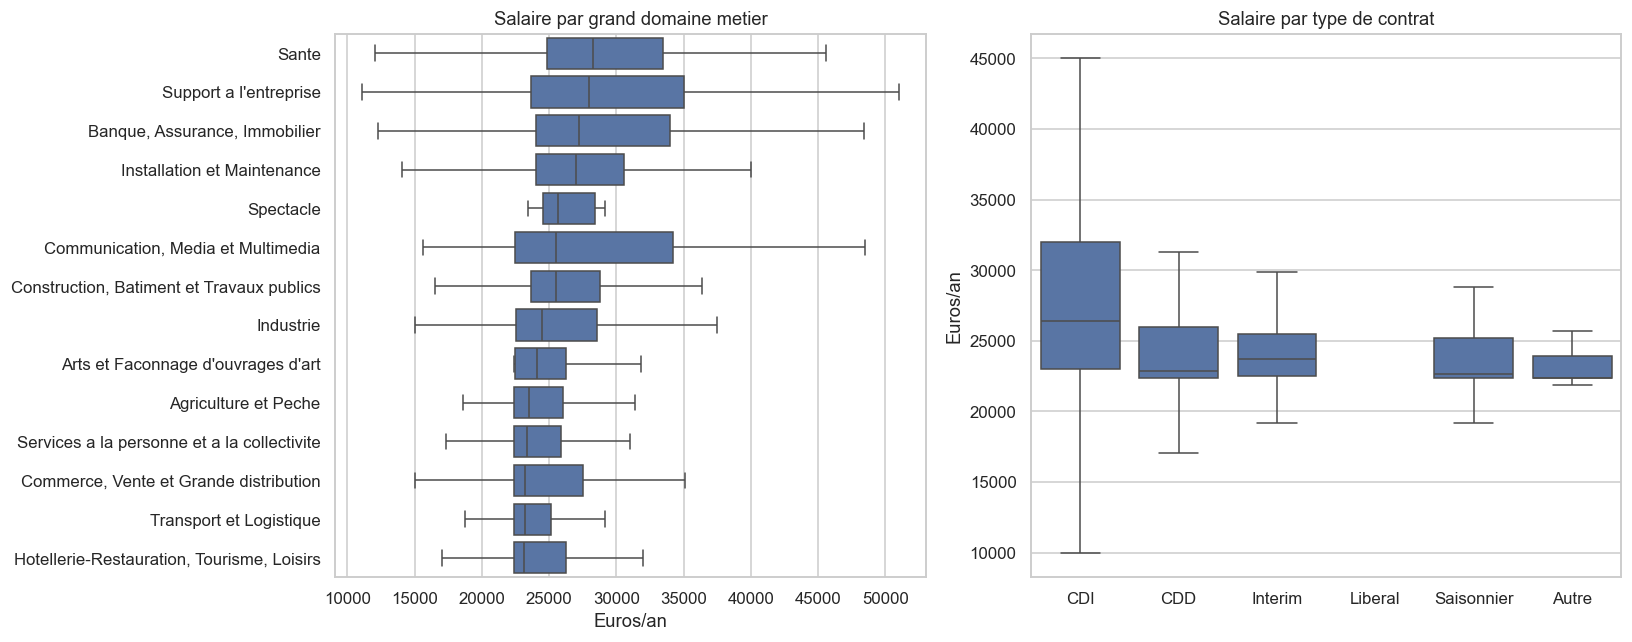

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
ordre = df.groupby('cible_metier')['salaire_annuel'].median().sort_values(ascending=False).index
sns.boxplot(data=df, y='cible_metier', x='salaire_annuel', order=ordre, ax=ax[0], showfliers=False)
ax[0].set(title='Salaire par grand domaine metier', xlabel='Euros/an', ylabel='')
sns.boxplot(data=df, x='cible_contrat', y='salaire_annuel', ax=ax[1], showfliers=False)
ax[1].set(title='Salaire par type de contrat', xlabel='', ylabel='Euros/an')
plt.tight_layout(); plt.show()

## B.4 Analyse geographique

Top 15 des departements qui recrutent le plus dans notre echantillon.

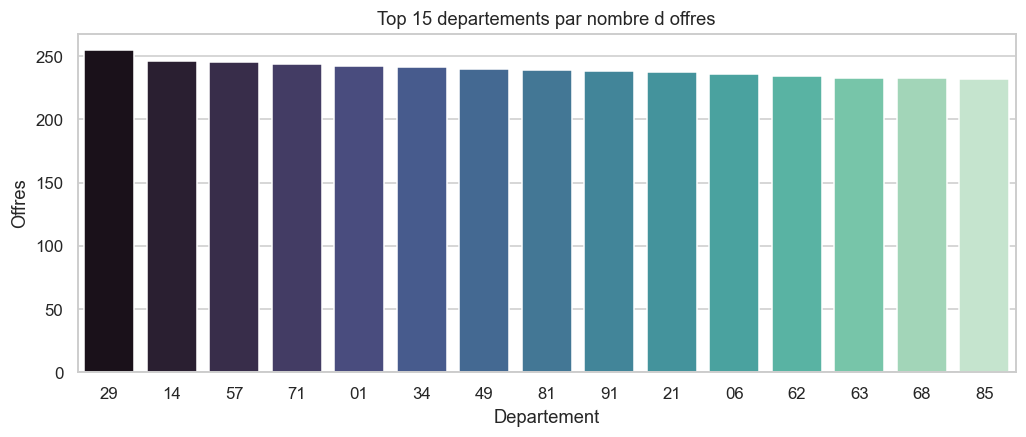

In [19]:
top_dep = df['departement'].value_counts().head(15)
plt.figure(figsize=(11, 4))
sns.barplot(x=top_dep.index, y=top_dep.values, palette='mako', hue=top_dep.index, legend=False)
plt.title('Top 15 departements par nombre d offres'); plt.xlabel('Departement'); plt.ylabel('Offres')
plt.show()

## B.5 Analyse textuelle

### B.5.1 Longueur des descriptions (apres lemmatisation)

count    19978.0
mean       108.0
std         65.0
min          5.0
25%         59.0
50%         96.0
75%        144.0
max        421.0
Name: nb_mots, dtype: float64


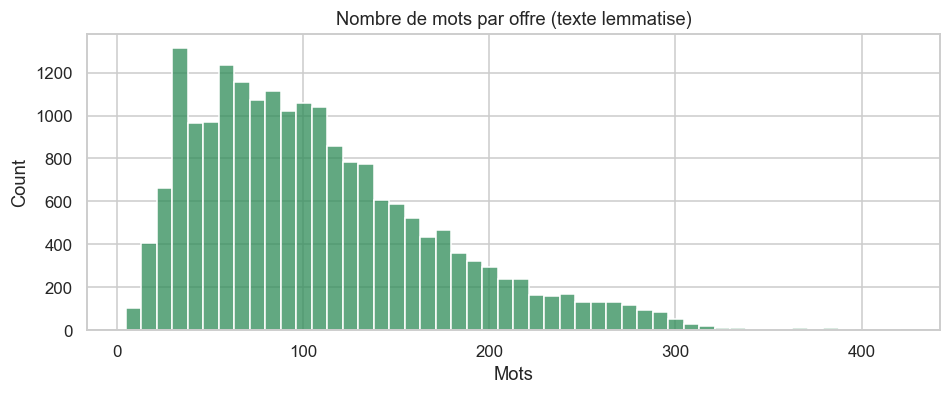

In [20]:
df['nb_mots'] = df['texte_lemmatise'].str.split().str.len()
print(df['nb_mots'].describe().round(0))
plt.figure(figsize=(10, 3.5))
sns.histplot(df['nb_mots'], bins=50, color='seagreen')
plt.title('Nombre de mots par offre (texte lemmatise)'); plt.xlabel('Mots'); plt.show()

### B.5.2 Mots les plus frequents

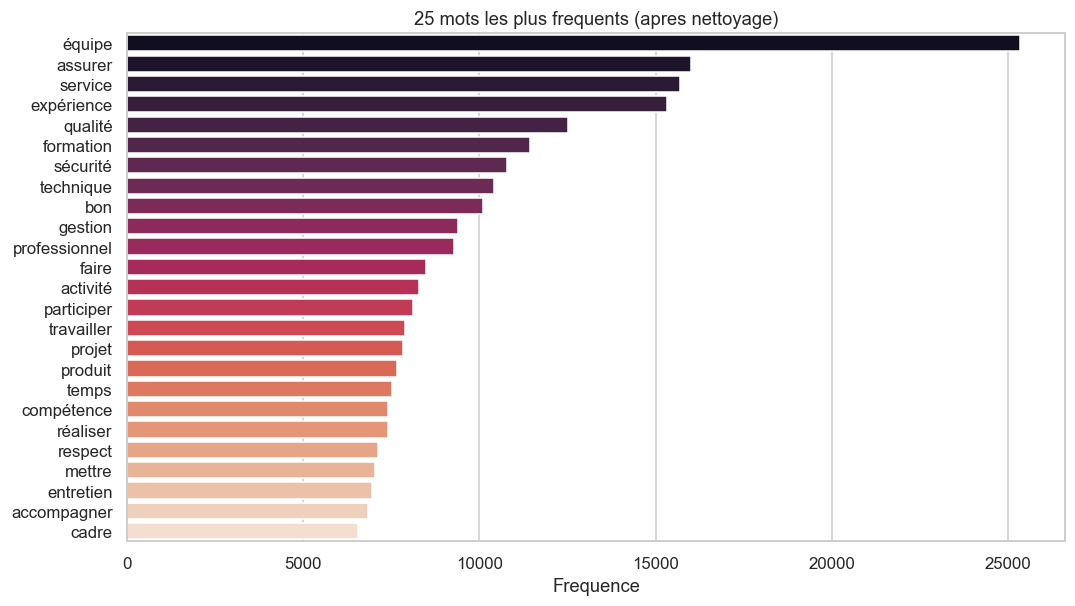

In [21]:
tous_mots = ' '.join(df['texte_lemmatise']).split()
freq = Counter(tous_mots).most_common(25)
mots, comptes = zip(*freq)
plt.figure(figsize=(11, 6))
sns.barplot(x=list(comptes), y=list(mots), palette='rocket', hue=list(mots), legend=False)
plt.title('25 mots les plus frequents (apres nettoyage)'); plt.xlabel('Frequence'); plt.show()

### B.5.3 Nuage de mots global

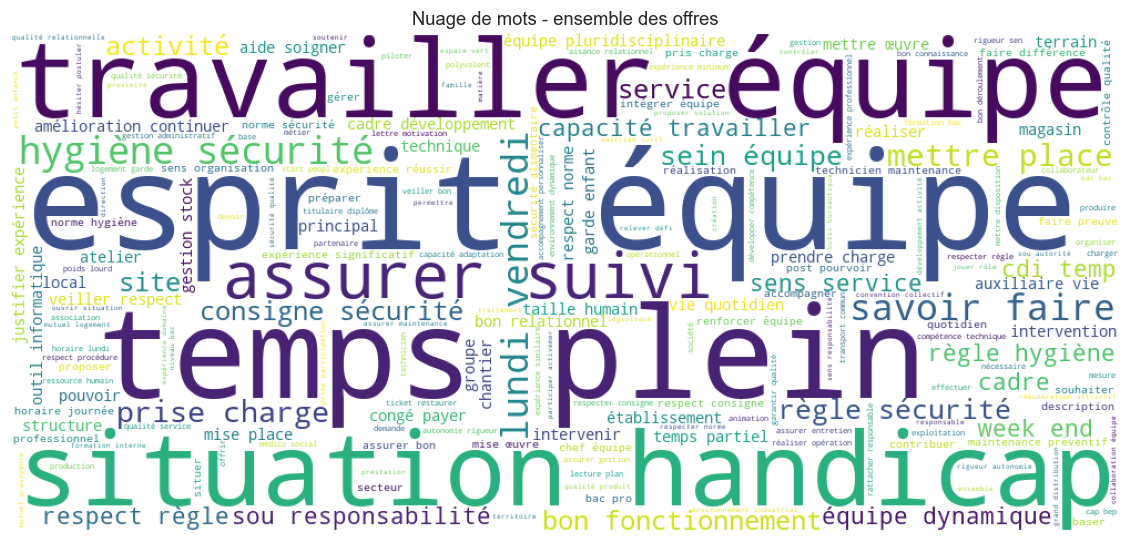

In [22]:
wc = WordCloud(width=1000, height=450, background_color='white', colormap='viridis')
wc.generate(' '.join(df['texte_lemmatise']))
plt.figure(figsize=(13, 6)); plt.imshow(wc); plt.axis('off')
plt.title('Nuage de mots - ensemble des offres'); plt.show()

### B.5.4 Nuages de mots par domaine metier

Ils montrent que le **vocabulaire differe nettement selon le metier** : c'est exactement ce qui rend la classification textuelle possible.

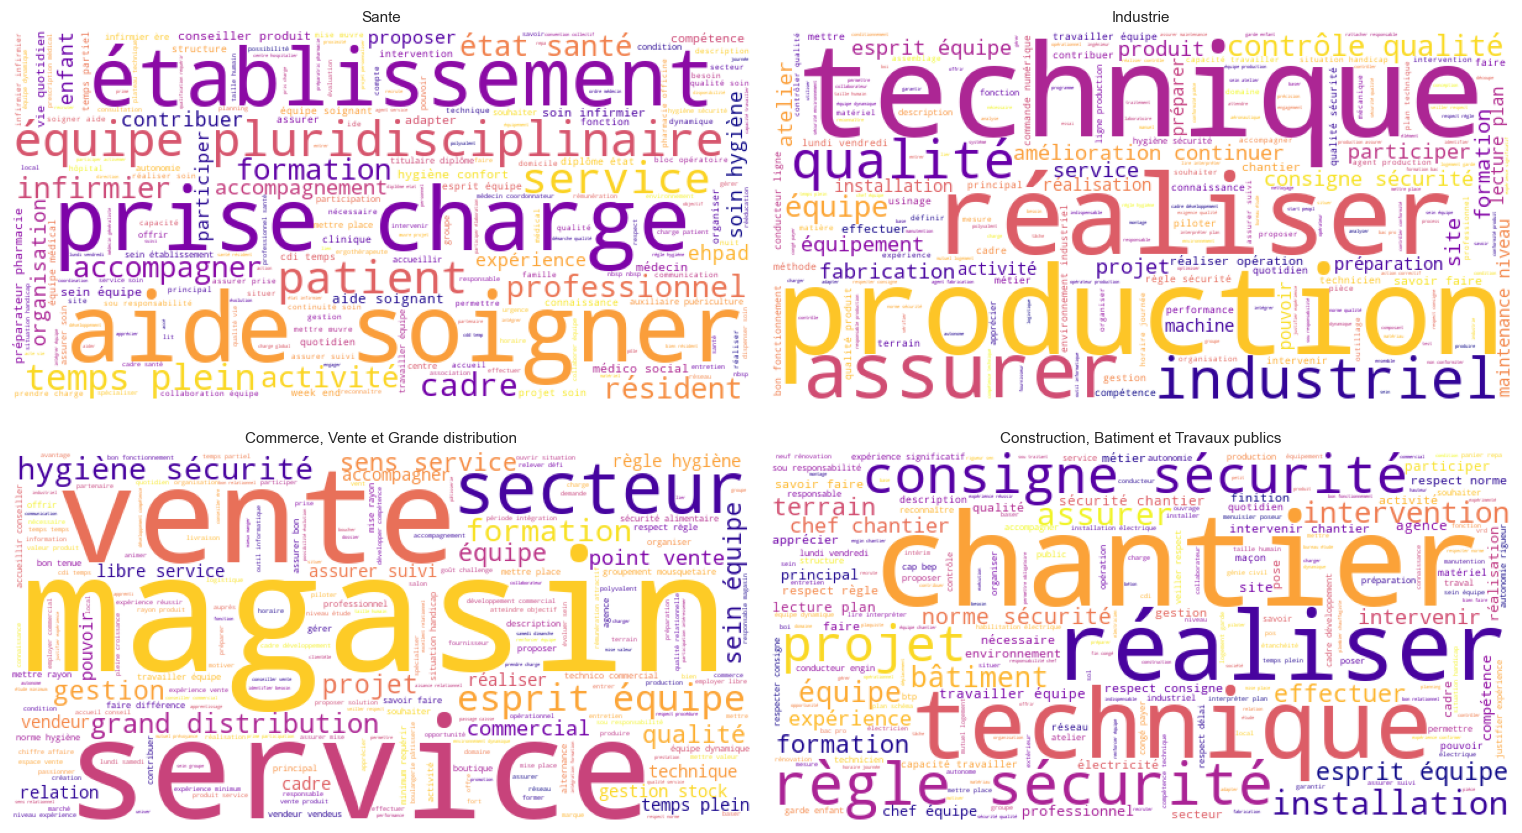

In [23]:
domaines = ['Sante', 'Industrie', 'Commerce, Vente et Grande distribution',
            'Construction, Batiment et Travaux publics']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, dom in zip(axes.ravel(), domaines):
    txt = ' '.join(df.loc[df['cible_metier'] == dom, 'texte_lemmatise'])
    if txt.strip():
        ax.imshow(WordCloud(width=600, height=300, background_color='white',
                            colormap='plasma').generate(txt))
    ax.set_title(dom, fontsize=10); ax.axis('off')
plt.tight_layout(); plt.show()

## B.6 Correlations entre variables numeriques

On regarde les liens lineaires entre salaire, experience demandee et temps plein.

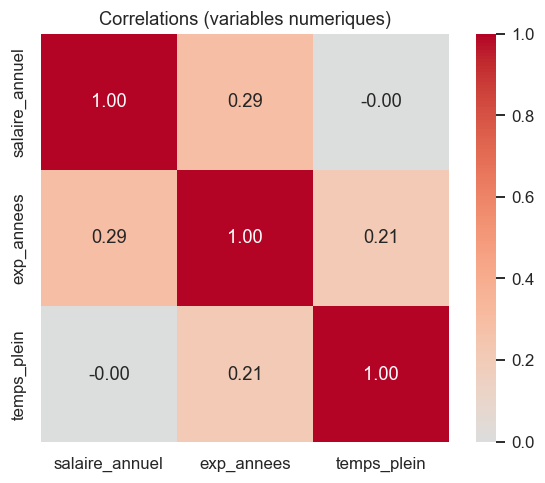

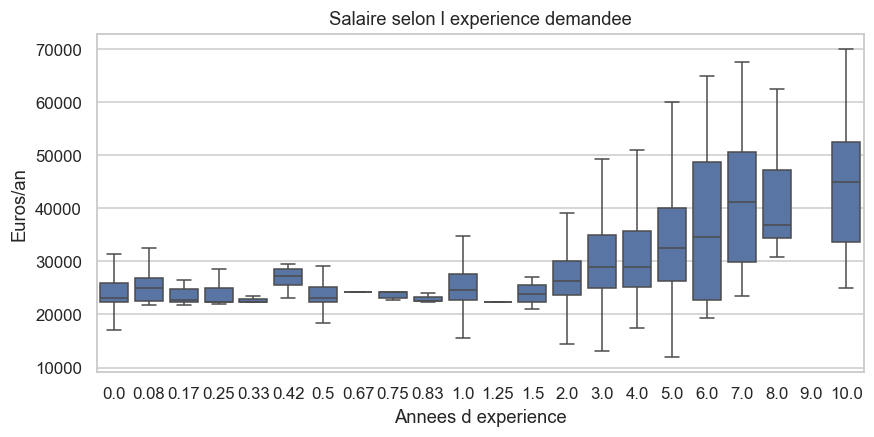

In [24]:
num = df[['salaire_annuel', 'exp_annees', 'temps_plein']].copy()
num['temps_plein'] = num['temps_plein'].astype('float')
corr = num.corr()
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Correlations (variables numeriques)'); plt.tight_layout(); plt.show()

plt.figure(figsize=(9, 4))
sns.boxplot(data=df[df['exp_annees'] <= 10], x='exp_annees', y='salaire_annuel', showfliers=False)
plt.title('Salaire selon l experience demandee'); plt.xlabel('Annees d experience'); plt.ylabel('Euros/an')
plt.show()

## B.7 Principaux enseignements

- **Salaire** : distribution asymetrique a droite, concentree autour de 22-28 k EUR/an ; varie fortement selon le **metier** (cadres/sante vs services) et le **type de contrat**.
- **Classes desequilibrees** : les services a la personne, l'industrie et le commerce dominent -> privilegier le **F1 macro** en classification.
- **Vocabulaire discriminant** par domaine -> la classification textuelle (BoW/TF-IDF/Doc2Vec/BERT) est pertinente.
- **Variables numeriques** (experience, temps plein, departement, contrat) -> exploitables pour la regression du salaire.

La suite portera sur la **modelisation** : regression du salaire (arbres, Random Forest, Boosting) et classification textuelle avec comparaison des methodes de vectorisation (BoW, TF-IDF, Doc2Vec, BERT).